In [49]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')


[*********************100%***********************]  1 of 1 completed


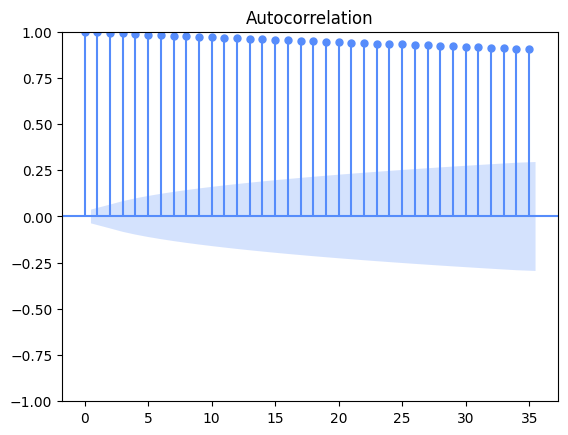

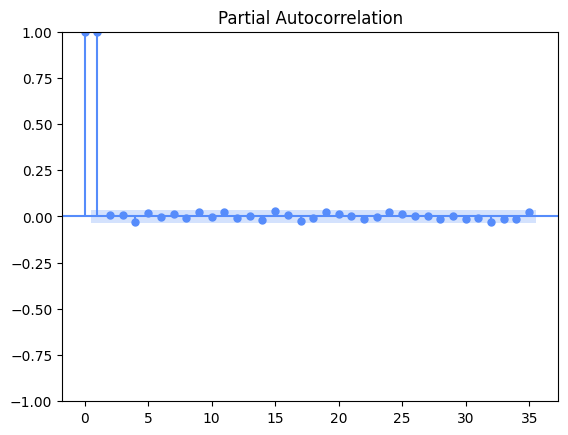

In [50]:
ticker = "DBB"
df = yf.download(ticker, start="2015-01-01", end="2026-01-01",auto_adjust=False,multi_level_index=False )
df = df[['Adj Close']]
df.rename(columns={'Adj Close': 'price'}, inplace=True)

from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

plot_acf(df['price'])
plot_pacf(df['price'])
plt.show()

In [51]:
window = 100
pred = []
params = []
date = []

for i in range(window,len(df)):

    train = df['price'].iloc[i-window:i]

    model = ARIMA(train, order=(1,1,1),trend='t').fit()
    forecast = model.forecast(steps = 1)

    pred.append(forecast.iloc[0])
    date.append(df.index[i])
    params.append(model.params)

params = pd.DataFrame(params,index=date)
results = pd.DataFrame({'prediction': pred}, index=date)
results['actual'] = df['price'].loc[results.index]
results['residual'] = results['actual'] - results['prediction']
results = results.join(params)


results['zscore'] = (
    results['residual'] - results['residual'].rolling(50).mean()
) / results['residual'].rolling(50).std()

results.dropna(inplace=True)

print(results)

            prediction     actual  residual        x1     ar.L1     ma.L1  \
2015-08-06   11.078131  11.024114 -0.054017 -0.012053  0.001501  0.001538   
2015-08-07   11.010943  10.957851 -0.053092 -0.012974  0.001831  0.001867   
2015-08-10   10.943394  11.156635  0.213241 -0.014149  0.002943  0.003005   
2015-08-11   11.156628  10.850180 -0.306449 -0.011913 -0.789236  0.883432   
2015-08-12   10.867645  10.916441  0.048796 -0.017671 -0.098488 -0.025542   
...                ...        ...       ...       ...       ...       ...   
2025-12-24   22.341537  22.389999  0.048463  0.036113 -0.422877  0.192150   
2025-12-26   22.434960  22.870001  0.435041  0.037034 -0.422714  0.200095   
2025-12-29   22.806878  22.480000 -0.326878  0.038619 -0.466294  0.241368   
2025-12-30   22.656876  23.020000  0.363125  0.035632 -0.487608  0.218292   
2025-12-31   22.855425  22.940001  0.084575  0.038944 -0.581129  0.267083   

              sigma2    zscore  
2015-08-06  0.016969 -0.219604  
2015-08-0

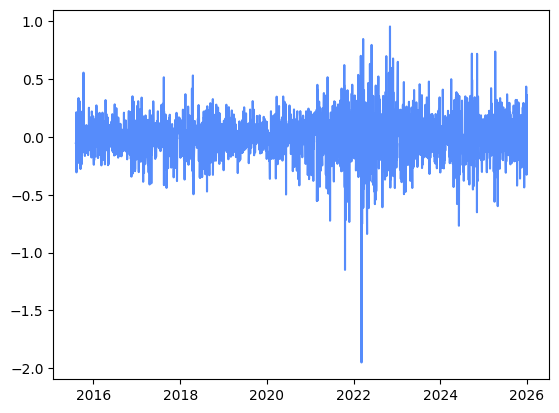

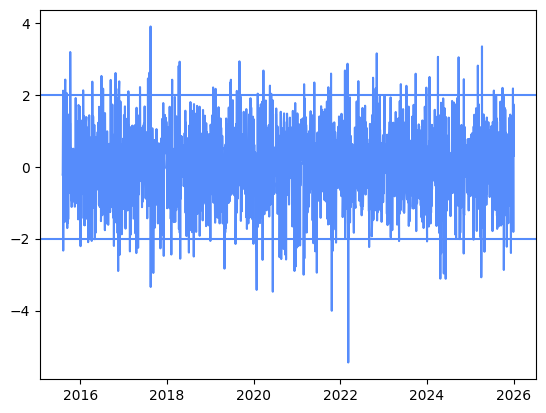

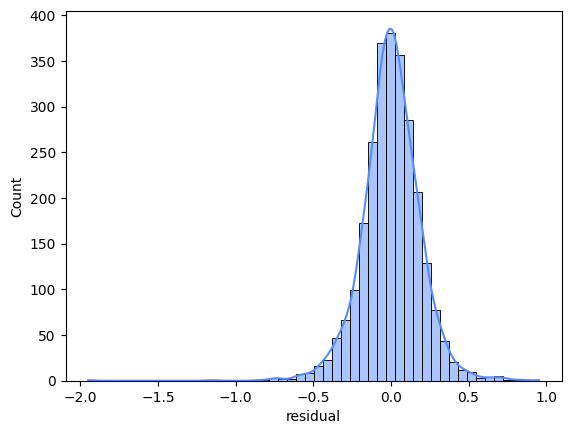

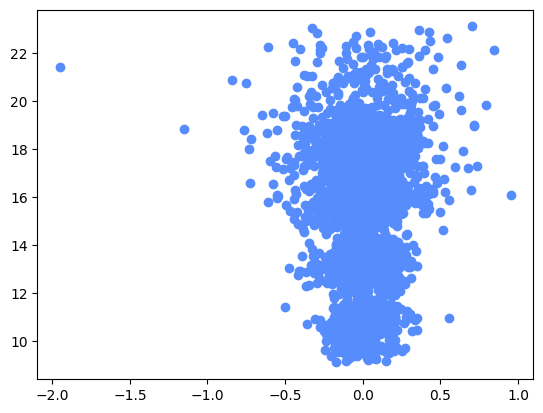

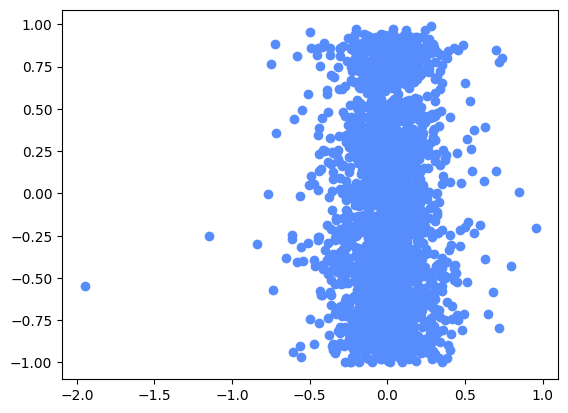

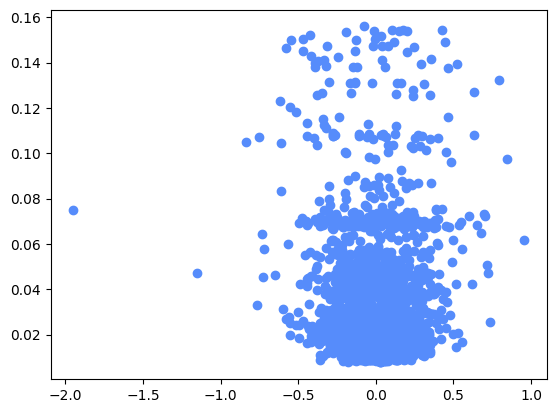

In [52]:
plt.plot(results['residual'])
plt.show()

plt.plot(results['zscore'])
plt.axhline(2)
plt.axhline(-2)
plt.show()

sns.histplot(results['residual'],kde=True, bins=50)
plt.show()

plt.scatter(results['residual'], results['actual'].shift(-1))
plt.show()

plt.scatter(results['residual'], results['ar.L1'])
plt.show()

plt.scatter(results['residual'], results['sigma2'])
plt.show()
